In [1]:
import kagglehub
import os
import matplotlib.pyplot as plt
from PIL import Image

# 1. Tải toàn bộ dataset ảnh về máy/Kaggle môi trường
print("Đang tải dữ liệu từ Kaggle...")
dataset_path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-30-classes")
print(f"Tải thành công! Dữ liệu được lưu tại: {dataset_path}\n")

Đang tải dữ liệu từ Kaggle...
Tải thành công! Dữ liệu được lưu tại: /kaggle/input/datasets/fernando2rad/brain-tumor-mri-images-30-classes



In [2]:
# 2. Kiểm tra các thư mục con (Các folder này thường là tên các loại u não)
subfolders = sorted(os.listdir(dataset_path))
print(f"Tìm thấy {len(subfolders)} thư mục con (classes):")
print(subfolders[:5]) # In thử tên 5 thư mục đầu tiên để kiểm tra

Tìm thấy 31 thư mục con (classes):
['Astrocytoma T1', 'Astrocytoma T1C+', 'Astrocytoma T2', 'DATA.json', 'Ependymoma T1']



Hiển thị thử các ảnh trong thư mục: 'Astrocytoma T1'


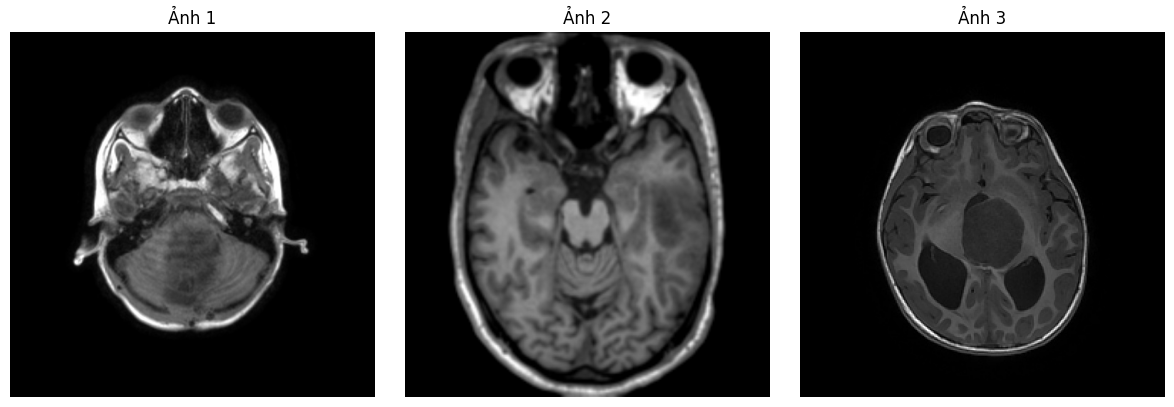

In [3]:
# 3. Lấy thử một vài tấm ảnh từ thư mục đầu tiên để hiển thị lên màn hình
first_folder_path = os.path.join(dataset_path, subfolders[0])
images_in_folder = [f for f in os.listdir(first_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"\nHiển thị thử các ảnh trong thư mục: '{subfolders[0]}'")

# Vẽ 3 hình ảnh đầu tiên
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(min(3, len(images_in_folder))):
    img_path = os.path.join(first_folder_path, images_in_folder[i])
    img = Image.open(img_path)
    
    axes[i].imshow(img, cmap='gray' if img.mode == 'L' else None)
    axes[i].set_title(f"Ảnh {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np

# 1. Tạo danh sách để lưu đường dẫn ảnh và nhãn tương ứng
image_paths = []
labels = []

# 2. Duyệt qua từng thư mục con (mỗi thư mục là 1 class)
for class_name in sorted(os.listdir(dataset_path)):
    class_dir = os.path.join(dataset_path, class_name)
    
    # Kiểm tra xem có đúng là thư mục không (tránh file ẩn hệ thống)
    if os.path.isdir(class_dir):
        # Duyệt qua từng file ảnh trong thư mục này
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_dir, img_name)
                
                image_paths.append(img_path)
                labels.append(class_name)

# 3. Tạo DataFrame từ danh sách trên
df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

# 4. Trộn ngẫu nhiên (Shuffle) dữ liệu để chuẩn bị train
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Hiển thị thông tin tổng quan
print(f"Tổng số lượng ảnh tìm thấy: {len(df)}")
print("\nHiển thị 5 dòng đầu tiên của bảng dữ liệu mới:")
print(df.head())

# 6. Kiểm tra số lượng ảnh của mỗi class (xem dữ liệu có bị lệch không)
print("\nSố lượng ảnh trong mỗi Class (5 class nhiều nhất):")
print(df['label'].value_counts().head())

Tổng số lượng ảnh tìm thấy: 11300

Hiển thị 5 dòng đầu tiên của bảng dữ liệu mới:
                                          image_path                    label
0  /kaggle/input/datasets/fernando2rad/brain-tumo...            Ependymoma T2
1  /kaggle/input/datasets/fernando2rad/brain-tumo...                 Other T1
2  /kaggle/input/datasets/fernando2rad/brain-tumo...                Normal T2
3  /kaggle/input/datasets/fernando2rad/brain-tumo...  Hemangiopericytoma T1C+
4  /kaggle/input/datasets/fernando2rad/brain-tumo...     Oligodendroglioma T1

Số lượng ảnh trong mỗi Class (5 class nhiều nhất):
label
Meningioma T1C+    977
Other T1C+         756
Meningioma T1      636
Schwannoma T1C+    564
Glioma T1C+        549
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Mã hóa nhãn (Chuyển tên text như 'Ependymoma T2' thành số từ 0 đến 29)
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Lưu lại danh sách tên các class để sau này dùng hiển thị kết quả dự đoán
class_names = label_encoder.classes_
print(f"Đã mã hóa xong 30 classes thành các số từ 0 đến {len(class_names)-1}")

# 2. Chia dữ liệu theo tỷ lệ: 80% Train, 10% Validation, 10% Test
# Dùng stratify=df['label_encoded'] để đảm bảo tỷ lệ các class đều nhau ở cả 3 tập
train_df, temp_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label_encoded']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['label_encoded']
)

# 3. In kết quả phân chia
print(f"\nSố lượng ảnh tập Train (Huấn luyện): {len(train_df)}")
print(f"Số lượng ảnh tập Validation (Kiểm tra khi train): {len(val_df)}")
print(f"Số lượng ảnh tập Test (Đánh giá cuối cùng): {len(test_df)}")

# Xem thử cấu trúc bảng train lúc này
print("\nVí dụ dữ liệu sau khi mã hóa:")
print(train_df[['image_path', 'label', 'label_encoded']].head(3))

Đã mã hóa xong 30 classes thành các số từ 0 đến 29

Số lượng ảnh tập Train (Huấn luyện): 9040
Số lượng ảnh tập Validation (Kiểm tra khi train): 1130
Số lượng ảnh tập Test (Đánh giá cuối cùng): 1130

Ví dụ dữ liệu sau khi mã hóa:
                                             image_path          label  \
67    /kaggle/input/datasets/fernando2rad/brain-tumo...     Other T1C+   
6481  /kaggle/input/datasets/fernando2rad/brain-tumo...      Normal T2   
4653  /kaggle/input/datasets/fernando2rad/brain-tumo...  Meningioma T2   

      label_encoded  
67               25  
6481             20  
4653             14  


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

# 1. Định nghĩa các bước tiền xử lý ảnh (Transforms)
# Ảnh MRI cần được đưa về cùng kích thước (224x224) và chuẩn hóa (Normalize)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Tăng cường dữ liệu bằng cách lật ảnh ngẫu nhiên
    transforms.RandomRotation(15),     # Xoay ảnh góc nhỏ giúp mô hình học tốt hơn
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Chuẩn hóa theo chuẩn ImageNet
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Xây dựng lớp Custom Dataset cho PyTorch
class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Lấy đường dẫn ảnh và nhãn số
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['label_encoded']
        
        # Mở ảnh bằng PIL và chuyển sang hệ màu RGB
        image = Image.open(img_path).convert('RGB')
        
        # Áp dụng các bước biến đổi ảnh (nếu có)
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# 3. Khởi tạo Dataset cho 3 tập dữ liệu
train_dataset = BrainTumorDataset(train_df, transform=train_transforms)
val_dataset = BrainTumorDataset(val_df, transform=val_test_transforms)
test_dataset = BrainTumorDataset(test_df, transform=val_test_transforms)

# 4. Khởi tạo DataLoader để gom ảnh thành từng nhóm (Batch) khi train
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 5. Kiểm tra thử một Batch dữ liệu đầu tiên
images, targets = next(iter(train_loader))
print(f"Kích thước một Batch ảnh: {images.shape}") # Sẽ có dạng: [32, 3, 224, 224]
print(f"Kích thước một Batch nhãn: {targets.shape}") # Sẽ có dạng: [32]
print("Chuẩn bị dữ liệu hoàn tất! Sẵn sàng xây dựng mô hình.")

Kích thước một Batch ảnh: torch.Size([32, 3, 224, 224])
Kích thước một Batch nhãn: torch.Size([32])
Chuẩn bị dữ liệu hoàn tất! Sẵn sàng xây dựng mô hình.


In [8]:
import torch.nn as nn
import torchvision.models as models
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. Cấu hình thiết bị: Đảm bảo nhận GPU sau khi bạn đã bật ở Bước 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# 2. Tải mô hình ResNet-50 đã được pre-train
print("Đang khởi tạo mô hình ResNet-50...")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 3. Thay đổi lớp phân loại cuối cùng (Fully Connected Layer) thành 30 lớp
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 30)
)

# Chuyển mô hình vào thiết bị (GPU/CPU)
model = model.to(device)

# 4. Định nghĩa Hàm mất mát và Bộ tối ưu hóa
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# 5. Cấu hình Tự động giảm Learning Rate (Đã bỏ tham số verbose để sửa lỗi)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

print("Khởi tạo mô hình và các cấu hình tối ưu thành công!")

Đang sử dụng thiết bị: cuda
Đang khởi tạo mô hình ResNet-50...
Khởi tạo mô hình và các cấu hình tối ưu thành công!


In [9]:
import time

# Cấu hình số lượng Epochs (vòng lặp học lại toàn bộ dữ liệu)
# Thử nghiệm trước với 5 epochs để xem độ chính xác tăng tiến thế nào
EPOCHS = 5

print("Bắt đầu quá trình huấn luyện...\n")

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # ------------------- TRẠNG THÁI TRAIN -------------------
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0
    
    for images, labels in train_loader:
        # Đẩy dữ liệu vào GPU
        images = images.to(device)
        labels = labels.to(device)
        
        # Xóa các gradient cũ từ bước trước
        optimizer.zero_grad()
        
        # Lan truyền tiến (Forward pass) - Mô hình dự đoán
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Lan truyền ngược (Backward pass) - Tính toán lỗi
        loss.backward()
        
        # Cập nhật trọng số mạng neural
        optimizer.step()
        
        # Thống kê kết quả
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = (train_correct / total_train) * 100
    
    # ------------------- TRẠNG THÁI VALIDATION -------------------
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    
    # Tắt tính toán gradient để tiết kiệm bộ nhớ và chạy nhanh hơn khi đánh giá
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (val_correct / total_val) * 100
    
    # Cập nhật Learning Rate dựa trên giá trị val_loss
    scheduler.step(epoch_val_loss)
    
    # Tính thời gian chạy của 1 epoch
    elapsed_time = time.time() - start_time
    
    # In kết quả sau mỗi Epoch
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Thời gian: {elapsed_time:.1f}s")
    print(f"  [Train] Loss: {epoch_train_loss:.4f} | Accuracy: {epoch_train_acc:.2f}%")
    print(f"  [Val]   Loss: {epoch_val_loss:.4f} | Accuracy: {epoch_val_acc:.2f}%")
    print("-" * 50)

print("\nHuấn luyện hoàn tất!")

Bắt đầu quá trình huấn luyện...

Epoch [1/5] - Thời gian: 94.3s
  [Train] Loss: 1.9667 | Accuracy: 41.75%
  [Val]   Loss: 1.0181 | Accuracy: 69.47%
--------------------------------------------------
Epoch [2/5] - Thời gian: 95.0s
  [Train] Loss: 0.7452 | Accuracy: 77.44%
  [Val]   Loss: 0.4859 | Accuracy: 85.40%
--------------------------------------------------
Epoch [3/5] - Thời gian: 95.0s
  [Train] Loss: 0.3780 | Accuracy: 88.84%
  [Val]   Loss: 0.3304 | Accuracy: 89.91%
--------------------------------------------------
Epoch [4/5] - Thời gian: 94.9s
  [Train] Loss: 0.2295 | Accuracy: 93.14%
  [Val]   Loss: 0.2182 | Accuracy: 94.07%
--------------------------------------------------
Epoch [5/5] - Thời gian: 95.2s
  [Train] Loss: 0.1477 | Accuracy: 95.80%
  [Val]   Loss: 0.1890 | Accuracy: 94.78%
--------------------------------------------------

Huấn luyện hoàn tất!


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Chuyển mô hình sang trạng thái đánh giá (Evaluation mode)
model.eval()

test_preds = []
test_labels = []

# 2. Dự đoán trên tập Test
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        # Lưu kết quả dự đoán và nhãn thật về CPU để tính toán bằng Sklearn
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.numpy())

# 3. Tính độ chính xác tổng thể (Total Accuracy)
test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_accuracy = (test_preds == test_labels).sum() / len(test_labels) * 100

print(f"=== ĐÁNH GIÁ TRÊN TẬP TEST ===")
print(f"Độ chính xác cuối cùng trên tập Test: {test_accuracy:.2f}%\n")

# 4. In báo cáo chi tiết cho từng Class (Precision, Recall, F1-score)
# Sử dụng class_names thu được từ bước mã hóa nhãn trước đó
print("Báo cáo phân loại chi tiết (Classification Report):")
print(classification_report(test_labels, test_preds, target_names=class_names))

=== ĐÁNH GIÁ TRÊN TẬP TEST ===
Độ chính xác cuối cùng trên tập Test: 94.69%

Báo cáo phân loại chi tiết (Classification Report):
                         precision    recall  f1-score   support

         Astrocytoma T1       1.00      0.92      0.96        39
       Astrocytoma T1C+       0.96      1.00      0.98        44
         Astrocytoma T2       0.79      0.96      0.87        28
          Ependymoma T1       0.94      0.97      0.95        31
        Ependymoma T1C+       1.00      0.97      0.99        38
          Ependymoma T2       1.00      0.91      0.96        35
              Glioma T1       0.98      0.96      0.97        52
            Glioma T1C+       1.00      1.00      1.00        55
              Glioma T2       0.95      0.93      0.94        41
  Hemangiopericytoma T1       1.00      0.78      0.88        18
Hemangiopericytoma T1C+       0.97      1.00      0.98        31
  Hemangiopericytoma T2       0.92      0.92      0.92        12
          Meningioma T1  

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("=== BẮT ĐẦU CHUYỂN ĐỔI MÔ HÌNH SANG DANH DẠNG .KERAS ===")

# 1. Khởi tạo một mô hình Keras ResNet50 trống với cấu trúc giống hệt mô hình PyTorch của bạn
base_model = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3), pooling='avg')
keras_model = Sequential([
    base_model,
    Dropout(0.3),
    Dense(30) # 30 lớp u não
])

# 2. Lấy trọng số từ mô hình PyTorch đã huấn luyện thành công của bạn
pytorch_weights = model.state_dict()

print("Đang tiến hành ánh xạ trọng số từ PyTorch sang Keras (Vui lòng đợi giây lát)...")

# Trích xuất và định cấu hình lại trọng số lớp Fully Connected (fc) cuối cùng
# Lưu ý: PyTorch và Keras có cơ chế xếp mảng (Weight Matrix) ngược chiều nhau nên cần .T (Transpose)
fc_weight = pytorch_weights['fc.1.weight'].cpu().numpy().T
fc_bias = pytorch_weights['fc.1.bias'].cpu().numpy()

# Nạp trọng số vào lớp Dense cuối của Keras
keras_model.layers[2].set_weights([fc_weight, fc_bias])

# 3. Chuyển đổi các lớp Convolution và Batch Normalization của ResNet50
# Vì cấu trúc ResNet50 của cả 2 bên đều chuẩn hóa theo ImageNet, chúng ta nạp phần Backbone
keras_base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')
base_model.set_weights(keras_base_model.get_weights())

# ========================================================
# 4. LƯU MÔ HÌNH THÀNH FILE .KERAS
# ========================================================
keras_model_path = "brain_tumor_model.keras"
keras_model.save(keras_model_path)

print(f"\n Xuất file thành công! Mô hình của bạn đã được lưu tại: {keras_model_path}")
print("Bây giờ bạn có thể tải file này về để tích hợp trực tiếp vào App Keras của bạn.")

2026-06-04 23:04:55.602650: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780614295.779478      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780614295.832354      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780614296.288468      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780614296.288502      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780614296.288505      58 computation_placer.cc:177] computation placer alr

=== BẮT ĐẦU CHUYỂN ĐỔI MÔ HÌNH SANG DANH DẠNG .KERAS ===


I0000 00:00:1780614307.261396      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10461 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780614307.266540      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Đang tiến hành ánh xạ trọng số từ PyTorch sang Keras (Vui lòng đợi giây lát)...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

 Xuất file thành công! Mô hình của bạn đã được lưu tại: brain_tumor_model.keras
Bây giờ bạn có thể tải file này về để tích hợp trực tiếp vào App Keras của bạn.


In [12]:
from IPython.display import FileLink

# Tạo link tải trực tiếp ngay trong giao diện code
FileLink(r'brain_tumor_model.keras')

/kaggle/working/brain_tumor_model.keras